In [1]:
import sklearn

In [2]:
import numpy as np
# numpy
# بتتعامل مع الأرقام
# arrays
# عمليات حسابية سريعة
# أساس أي شغل machine learning

import pandas as pd
# pandas
# قراءة الداتا
# تنظيمها في جداول
# تنظيف الداتا
# التعامل مع CSV و Excel

import matplotlib.pyplot as plt
# matplotlib
# رسم الجرافات
# عرض العلاقة بين المتغيرات
# فهم شكل الداتا بصريًا

from sklearn.model_selection import train_test_split
# train_test_split
# تقسيم الداتا
# جزء للتدريب
# جزء للاختبار
# علشان تتأكد إن الموديل مش حافظ الداتا

from sklearn.linear_model import LinearRegression
# LinearRegression
# موديل الانحدار الخطي
# بيحسب العلاقة بين X و Y
# بيطلع معادلة التوقع
# أساس house price prediction

from sklearn.metrics import mean_squared_error, r2_score
# mean_squared_error
# يقيس متوسط الخطأ
# كل ما يقل الرقم الموديل أحسن

# r2_score
# يقيس قوة الموديل
# من 0 لـ 1
# كل ما يقرب من 1 يبقى أحسن

from sklearn.datasets import fetch_california_housing
# fetch_california_housing
# داتا جاهزة
# أسعار بيوت في كاليفورنيا
# للتجربة والتعلم
# من غير ما تجمع داتا بنفسك


## 1 . Data collection

In [3]:
housing = fetch_california_housing()

In [4]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [5]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [6]:
df


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [7]:
df['PRICE'] = housing.target

In [8]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## 2. Extract Features (X)

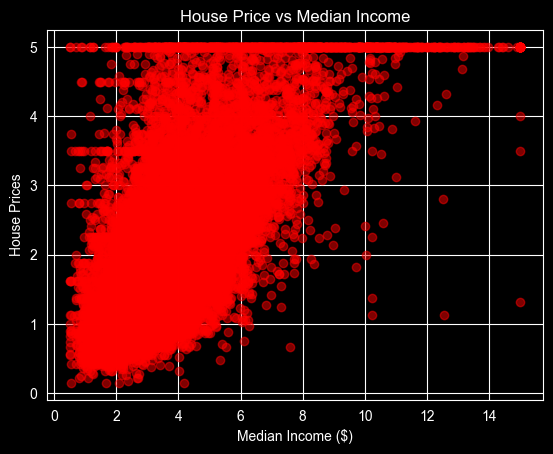

In [9]:
plt.scatter(df['MedInc'], df['PRICE'] , color = 'red' , alpha = 0.5)
plt.xlabel('Median Income ($)')
plt.ylabel('House Prices')
plt.title('House Price vs Median Income')
plt.show()

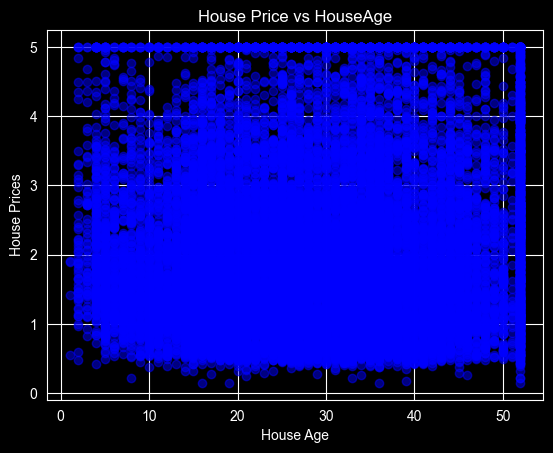

In [10]:
plt.scatter(df['HouseAge'], df['PRICE'] , color = 'Blue' , alpha = 0.5)
plt.xlabel('House Age')
plt.ylabel('House Prices')
plt.title('House Price vs HouseAge')
plt.show()

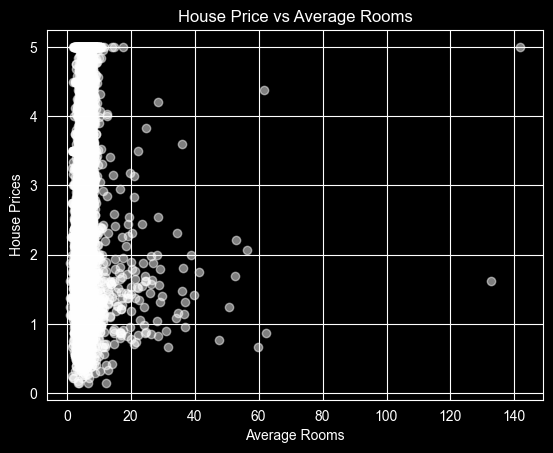

In [11]:
plt.scatter(df['AveRooms'], df['PRICE'] , color = 'white' , alpha = 0.5)
plt.xlabel('Average Rooms')
plt.ylabel('House Prices')
plt.title('House Price vs Average Rooms')
plt.show()

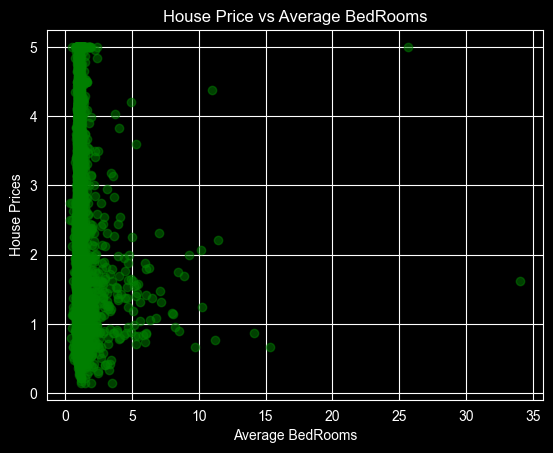

In [12]:
# AveBedrms

plt.scatter(df['AveBedrms'], df['PRICE'] , color = 'green' , alpha = 0.5)
plt.xlabel('Average BedRooms')
plt.ylabel('House Prices')
plt.title('House Price vs Average BedRooms')
plt.show()

C:\Users\CS\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


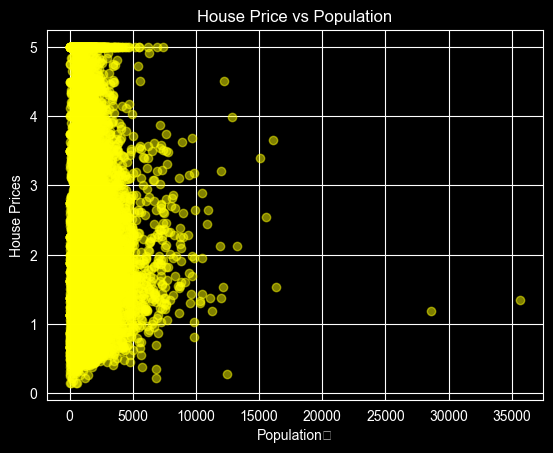

In [13]:

plt.scatter(df['Population'], df['PRICE'] , color = 'yellow' , alpha = 0.5)
plt.xlabel('Population	')
plt.ylabel('House Prices')
plt.title('House Price vs Population')
plt.show()

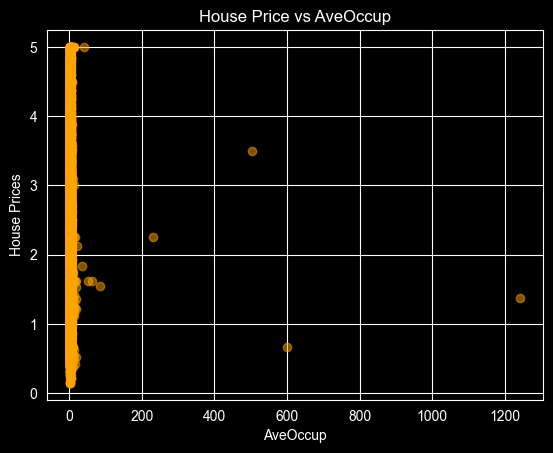

In [14]:

plt.scatter(df['AveOccup'], df['PRICE'] , color = 'orange' , alpha = 0.5)
plt.xlabel('AveOccup')
plt.ylabel('House Prices')
plt.title('House Price vs AveOccup')
plt.show()

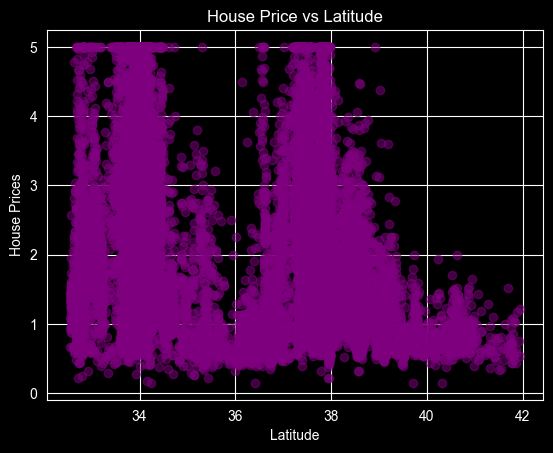

In [15]:

plt.scatter(df['Latitude'], df['PRICE'] , color = 'purple' , alpha = 0.5)
plt.xlabel('Latitude')
plt.ylabel('House Prices')
plt.title('House Price vs Latitude')
plt.show()

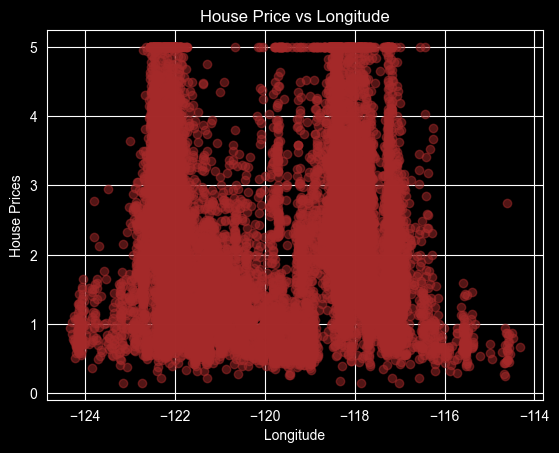

In [16]:
# Longitude

plt.scatter(df['Longitude'], df['PRICE'] , color = 'brown' , alpha = 0.5)
plt.xlabel('Longitude')
plt.ylabel('House Prices')
plt.title('House Price vs Longitude')
plt.show()

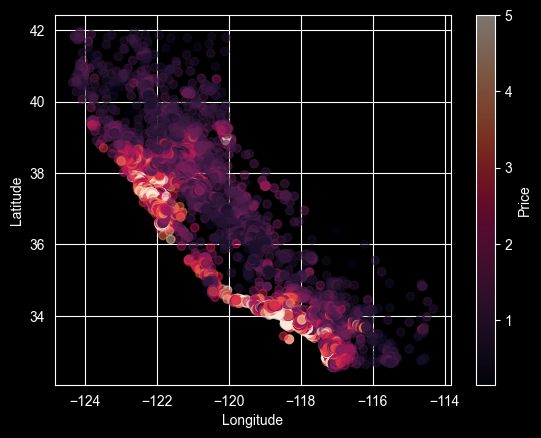

In [17]:
plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["PRICE"],
    alpha=0.5
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Price")
plt.show()


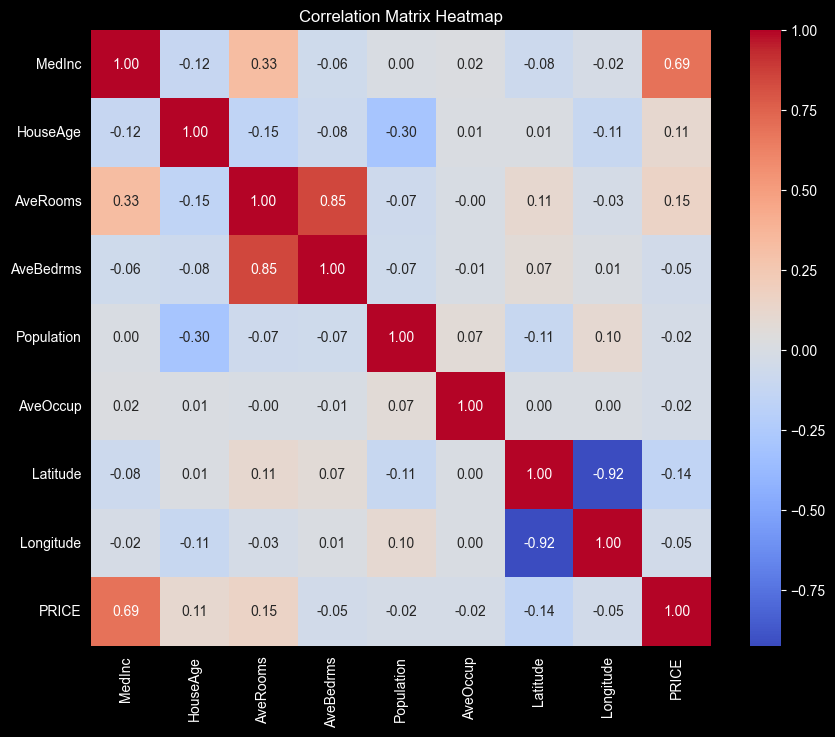

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# نختار الأعمدة الرقمية فقط
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# نرسم heatmap للمصفوفة
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()


### 3 . prepare and split Data


In [19]:
features_to_explore = ['MedInc' , 'AveRooms' , 'HouseAge' , 'Population' , 'AveBedrms' , 'AveOccup']


In [20]:
X = df [features_to_explore]
y = df['PRICE']

In [21]:
X

,MedInc,AveRooms,HouseAge,Population,AveBedrms,AveOccup
0,8.3252,6.984127,41.0,322.0,1.023810,2.555556
1,8.3014,6.238137,21.0,2401.0,0.971880,2.109842
2,7.2574,8.288136,52.0,496.0,1.073446,2.802260
3,5.6431,5.817352,52.0,558.0,1.073059,2.547945
4,3.8462,6.281853,52.0,565.0,1.081081,2.181467
...,...,...,...,...,...,...
20635,1.5603,5.045455,25.0,845.0,1.133333,2.560606
20636,2.5568,6.114035,18.0,356.0,1.315789,3.122807
20637,1.7000,5.205543,17.0,1007.0,1.120092,2.325635
20638,1.8672,5.329513,18.0,741.0,1.171920,2.123209


In [22]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: PRICE, Length: 20640, dtype: float64

In [23]:
X_train, X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

### 4. train the Model

In [24]:


model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 5. Make prediction

In [25]:
y_pred = model.predict(X_test)


In [26]:
print("Comparison of Actual vs Predicted Values")
for actual , predicted in list (zip(y_test[:10], y_pred[:10])):
    print("Actual:", round(actual, 2), " | Predicted:", round(predicted, 2))

Comparison of Actual vs Predicted Values
Actual: 0.48  | Predicted: 1.0
Actual: 0.46  | Predicted: 1.56
Actual: 5.0  | Predicted: 2.68
Actual: 2.19  | Predicted: 2.65
Actual: 2.78  | Predicted: 1.98
Actual: 1.59  | Predicted: 2.18
Actual: 1.98  | Predicted: 2.66
Actual: 1.57  | Predicted: 2.17
Actual: 3.4  | Predicted: 2.43
Actual: 4.47  | Predicted: 4.23


### 6. Evaluate

In [27]:
r2 = r2_score(y_test, y_pred)

In [30]:
r2


0.5099337366296386

In [31]:
'''
r2 =< 0.30 bad
r2 0.40 --> 0.60 low
r2 0.60 ---> 0.70 good
r2 => 0.75 good
'''

'\nr2 =< 0.30 bad\nr2 0.40 --> 0.60 low\nr2 0.60 ---> 0.70 good\nr2 => 0.75 good\n'